1.EDA


In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv to online_retail (1).csv


In [17]:
import pandas as pd

df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [18]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303

In [19]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

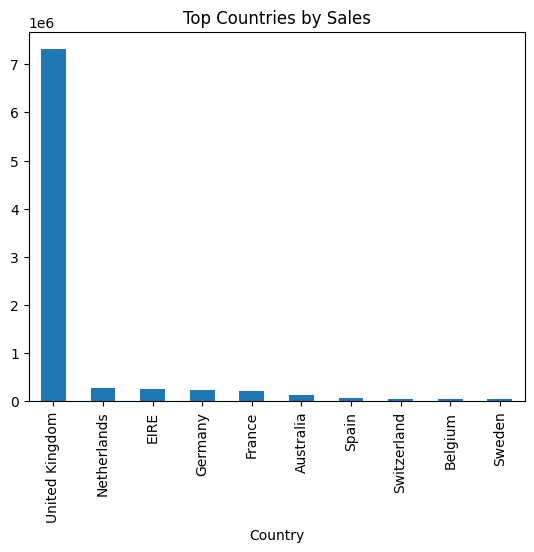

In [21]:
country = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)

country.head(10).plot(kind="bar")
plt.title("Top Countries by Sales")
plt.show()

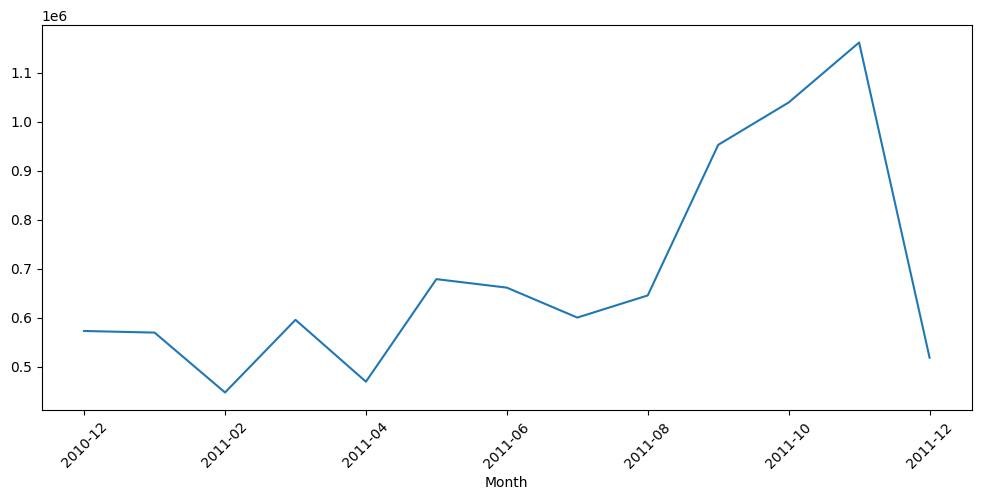

In [22]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly = df.groupby("Month")["TotalAmount"].sum()

plt.figure(figsize=(12,5))
monthly.plot()
plt.xticks(rotation=45)
plt.show()

Feature Extraction

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum",
    "Quantity": "sum",
    "Country": lambda x: x.mode()[0]
}).reset_index()

rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "Country"
]

In [25]:
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
rfm["Country"] = le.fit_transform(rfm["Country"])

Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "Country"
]

scaler = StandardScaler()
scaled = scaler.fit_transform(rfm[features])

PCA

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled)

print(pca.explained_variance_ratio_)

[0.43126018 0.1885502 ]


PCA Plot

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10)
plt.title("PCA Projection")
plt.show()

In [29]:
import os

# Create outputs folder
os.makedirs("outputs", exist_ok=True)

# Save customer-level features
rfm.to_csv("outputs/customer_features.csv", index=False)

print("customer_features.csv saved successfully!")

customer_features.csv saved successfully!


In [30]:
rfm.to_csv("customer_features.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [31]:
from google.colab import drive
drive.mount('/content/drive')

rfm.to_csv('/content/drive/MyDrive/customer_features.csv', index=False)
print("Saved to Google Drive")

Mounted at /content/drive
Saved to Google Drive


In [32]:
rfm.to_csv("customer_features.csv", index=False)

from google.colab import files
files.download("customer_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>